# T03 — Projection cookbook

**Eight different map projections of the same reconstructed coastlines at 90 Ma.**

## What this notebook produces

Eight standalone `pygmt.Figure` panels of the same 90 Ma snapshot, each rendered in a different map projection: Robinson, Mollweide, Hammer, Sinusoidal, Mercator-clipped, orthographic, south-polar stereographic, and azimuthal equidistant. The data is identical in every panel — only the projection (and where necessary the region clip) changes — so the differences you see are pure cartographic-distortion differences.

## What you will learn

1. How to write a projection helper that takes `(projection, title, region)` and renders one panel.
2. Why mixed-aspect-ratio projections can't share a `pygmt.subplot` cell, and how the one-figure-per-projection pattern sidesteps that.
3. Why **Mercator** needs a region clip (`±80°` lat) and **polar stereographic** wants a hemisphere clip — i.e. when the GMT `region` and `projection` arguments are coupled.

**Audience**: undergraduate.  
**Difficulty**: ★☆☆.  
**Runtime**: ≈30 s.

## Learning objectives

- Render the same reconstructed Earth in six pyGMT projection families (Robinson, Mollweide, Hammer, orthographic, polar stereographic, Mercator).
- Understand when each projection is appropriate (global vs. regional, equator-centred vs. pole-centred).
- Switch projections by editing one string — the rest of the rendering pipeline stays unchanged.


## Prerequisites and runtime

- **Plate model**: Zahirovic 2022.
- **Reconstruction time**: 50 Ma (representative late-Eocene snapshot).
- **Python**: `gplately`, `pygmt`, `pygplates`.
- **Runtime**: ~1 minute (six small maps).


In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import gplately
import pygmt
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

print(f"gplately {gplately.__version__} · pygmt {pygmt.__version__}")

# Suite-wide tutorial style: bigger panel titles, 1cm gap between figures.
pygmt.config(FONT_TITLE="18p", FONT_LABEL="18p",
             FONT_ANNOT_PRIMARY="14p")

gplately 2.0.0.post19+git.2cce7bb3 · pygmt v0.18.0


## Configuration

User-tunable choices for this notebook. Edit the values below to change the model, snapshot time, region, or anchor plate without hunting through downstream code.


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME           = "Zahirovic2022"
RECONSTRUCTION_TIME  = 50.0          # Ma — common snapshot across all projections
ANCHOR_PLATE_ID      = 0
REGION_GLOBAL        = [-180, 180, -80, 80]
REGION_POLAR_SOUTH   = [-180, 180, -90, -30]
# ============================================================================


## Set up a single 90 Ma snapshot

We pick 90 Ma — well after the Atlantic opens but before the Indian collision — to give the map enough motion to be visually interesting.

In [3]:
# Cell 2 — build the snapshot once
TIME = 90  # Ma

pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")

recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=TIME,

plot_engine=gplately.PygmtPlotEngine(),
)


## A helper that plots the same data on any projection

We define a single function and then call it eight times with different `projection` strings.

See pyGMT's [projections reference](https://www.pygmt.org/latest/projections/index.html) for the full string syntax. The patterns used below:

| String           | Projection                              |
|------------------|-----------------------------------------|
| `R0/15c`         | Robinson, centred at 0°, 15 cm wide      |
| `W0/15c`         | Mollweide                                |
| `H0/15c`         | Hammer                                   |
| `N0/15c`         | Sinusoidal                                |
| `M0/15c`         | Mercator (cylindrical)                    |
| `G0/0/15c`       | Orthographic from (0°N, 0°E)              |
| `S0/-90/15c`     | South polar stereographic                 |
| `E0/0/15c`       | Azimuthal equidistant from (0°N, 0°E)     |

In [4]:
# Cell 3 — projection helper
def draw_panel(fig, projection, title, region):
    fig.basemap(region=region, projection=projection,
                frame=["af", f'+t{title}'])
    gplot.plot_continents(fig, fill="gray95", pen="0.2p,gray30")
    gplot.plot_coastlines(fig, pen="0.3p,gray20")
    # Continuous plate-boundary backbone (incl. "other" segments
    # that aren't classified as ridge / transform / subduction — these are
    # the connection points that would otherwise leave gaps in the network).
    # Draw this FIRST so ridges, transforms and trenches render on top with
    # their distinctive colours. Pattern follows the Dixon A24 reference.
    gplot.plot_all_topological_sections(fig, pen="0.5p,gray50")

    gplot.plot_ridges(fig, pen="0.5p,red")
    (_tl, _tr) = gplot.get_subduction_direction()
    gplot.plot_subduction_teeth(fig, color="blue")

## Render eight panels

We render each projection in its own `pygmt.Figure` and let the notebook scroll through them. *Why not a single `pygmt.subplot`?* GMT's `subplot` allocates every cell the same width and height, but the projections below have two very different aspect ratios — pseudo-cylindrical projections (Robinson, Mollweide, Hammer, Sinusoidal) are roughly **2 : 1** (wide and short), while the circular projections (Mercator-clipped, orthographic, polar stereographic, azimuthal equidistant) are roughly **1 : 1** (square). Mixing both classes into one uniform-cell subplot makes the frame size disagree with the map size — the canonical fix is to drop `subplot` and render one figure per projection.

### What the eight panels reveal

Scroll the eight figures and pay attention to what each projection trades off:

- **Robinson, Mollweide, Hammer, Sinusoidal** are *equal-area* or near-equal-area pseudo-cylindrical projections. They are the default choice for global paleo-maps because they preserve continent sizes faithfully.
- **Mercator** is *conformal* (preserves local angles) but wildly area-distorting at high latitudes. Hence the ±80° clip — without it the projection diverges at the poles.
- **Orthographic** is what a paleo-Earth looks like from space: the visible hemisphere is rendered, the back hemisphere is clipped. Useful for "globe view" hero shots.
- **Polar stereographic** is the conventional choice for Antarctic/Arctic close-ups — it is conformal at the pole.
- **Azimuthal equidistant** preserves distances *from a chosen centre point*. Useful for trajectory analyses (e.g. plate-motion trajectories around an Euler pole).

90 Ma — same data, eight projections


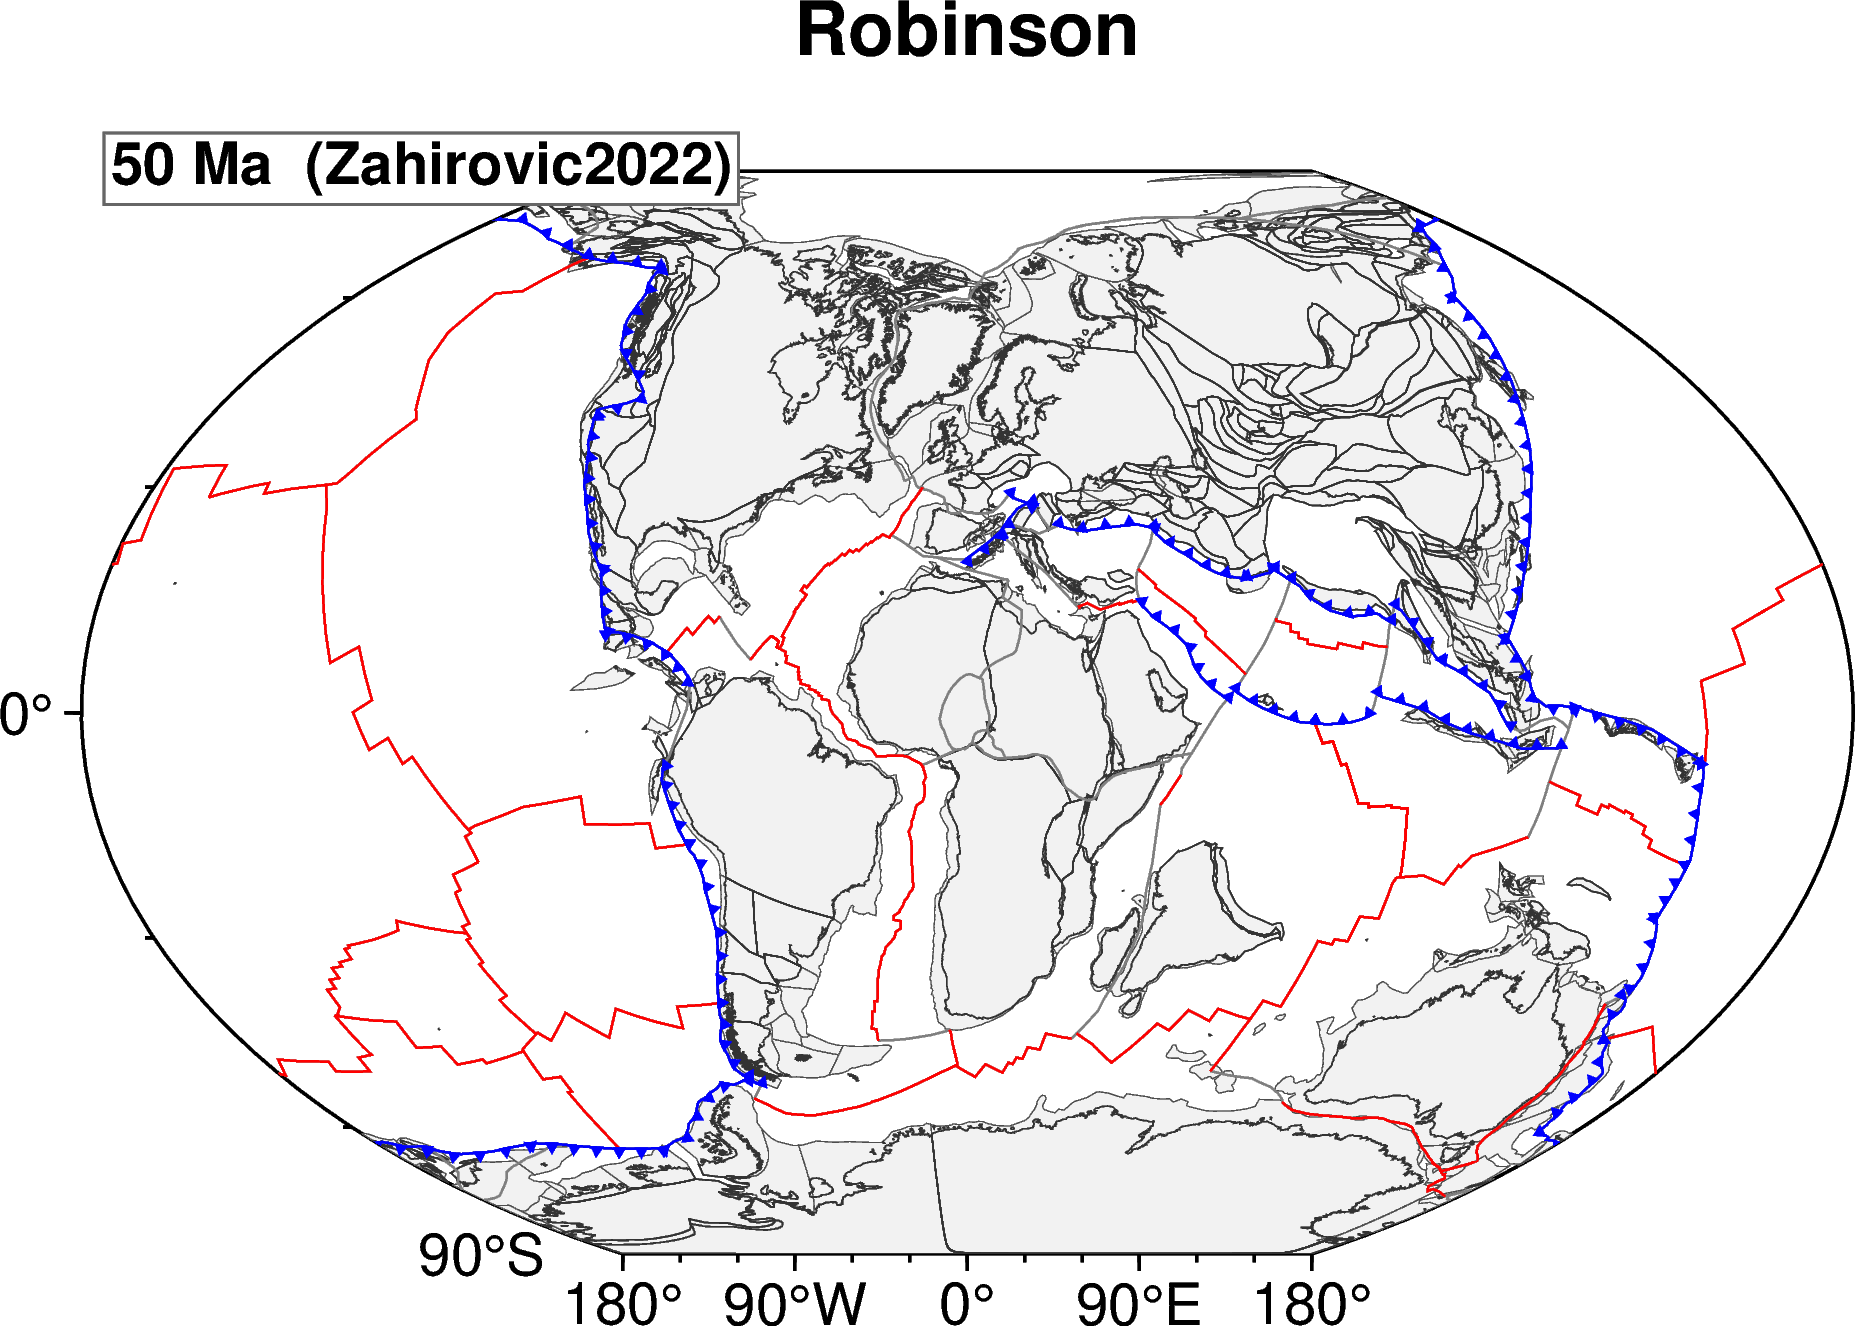

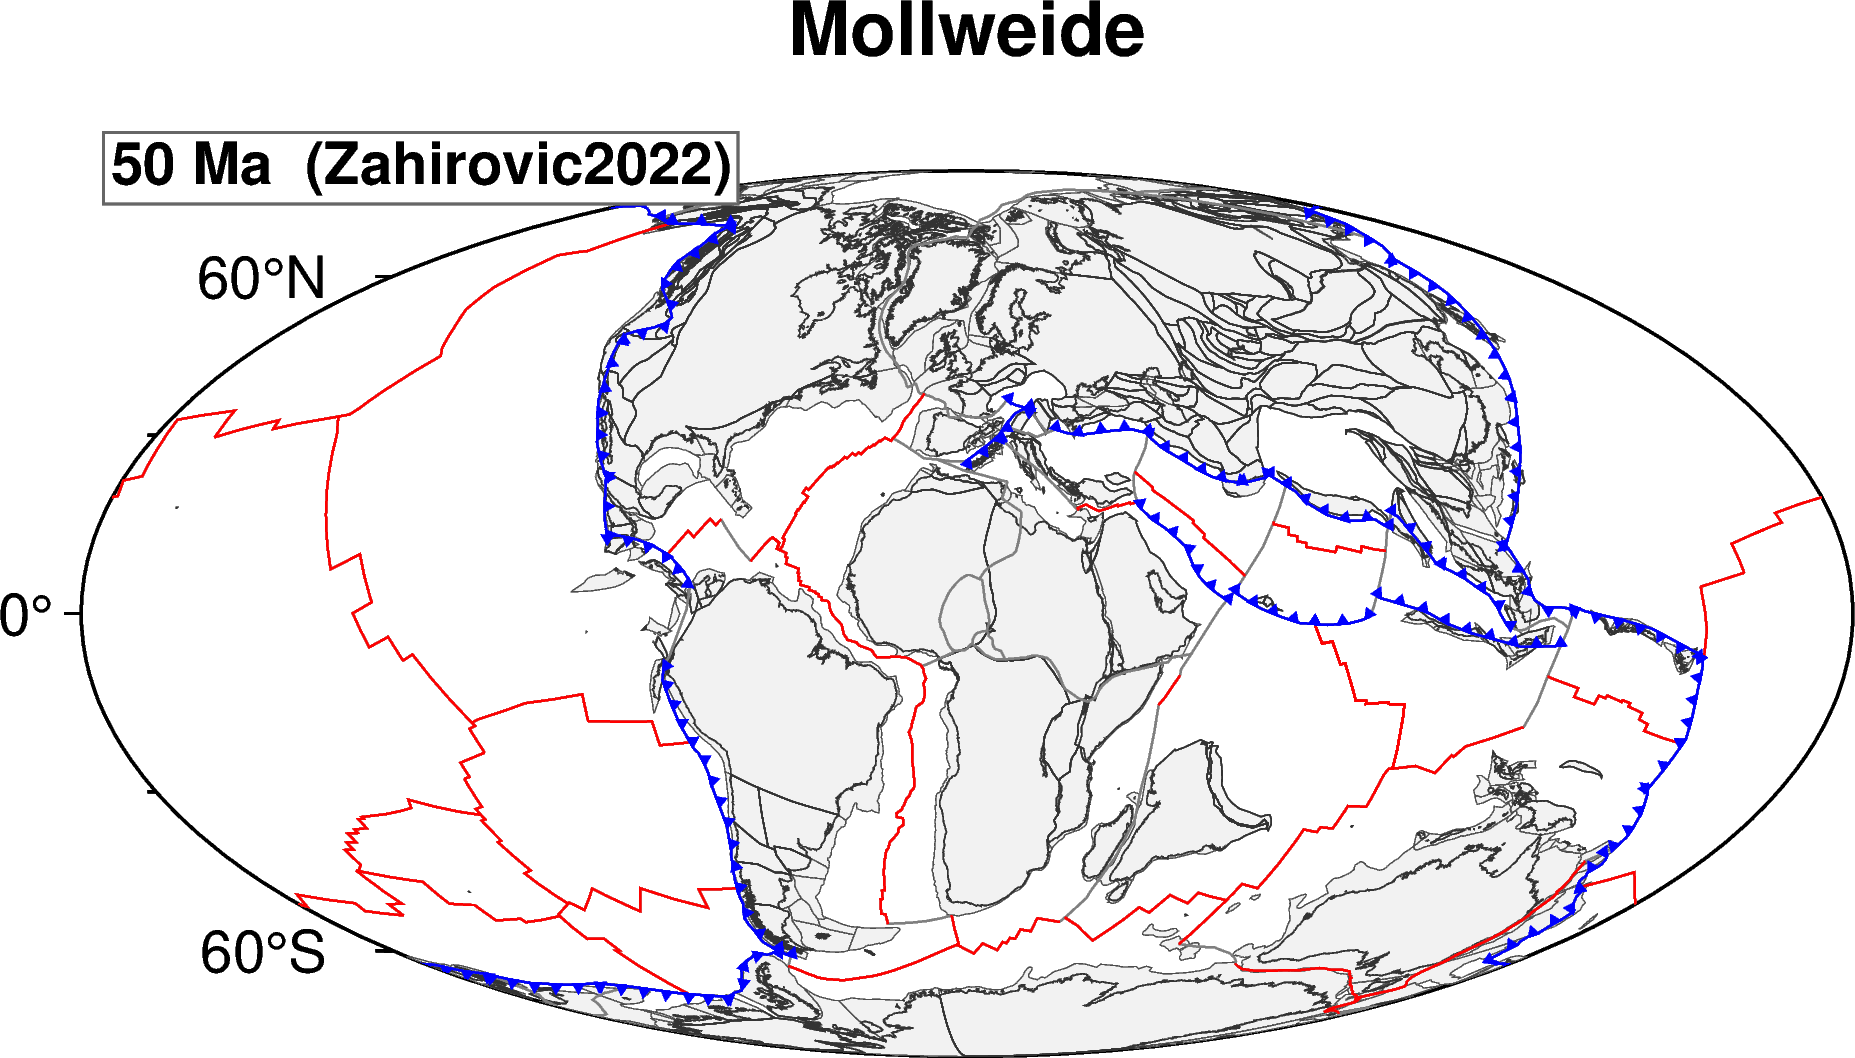

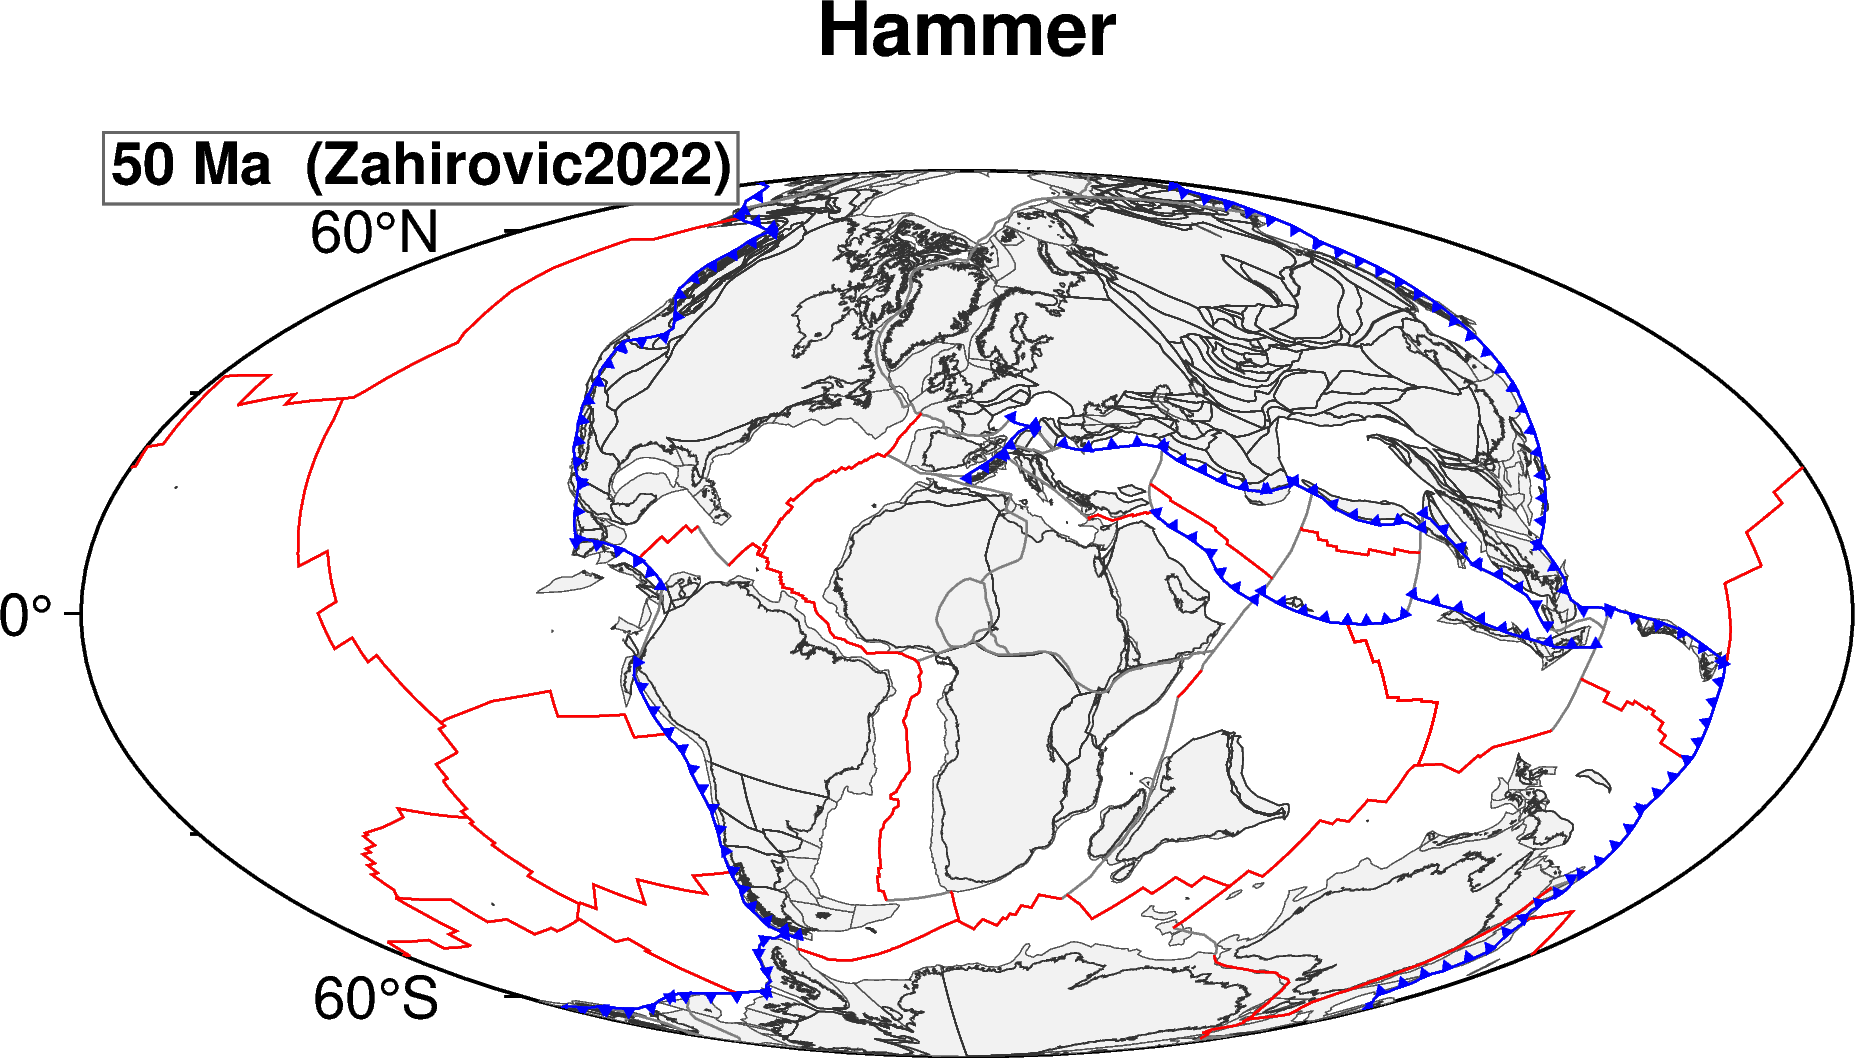

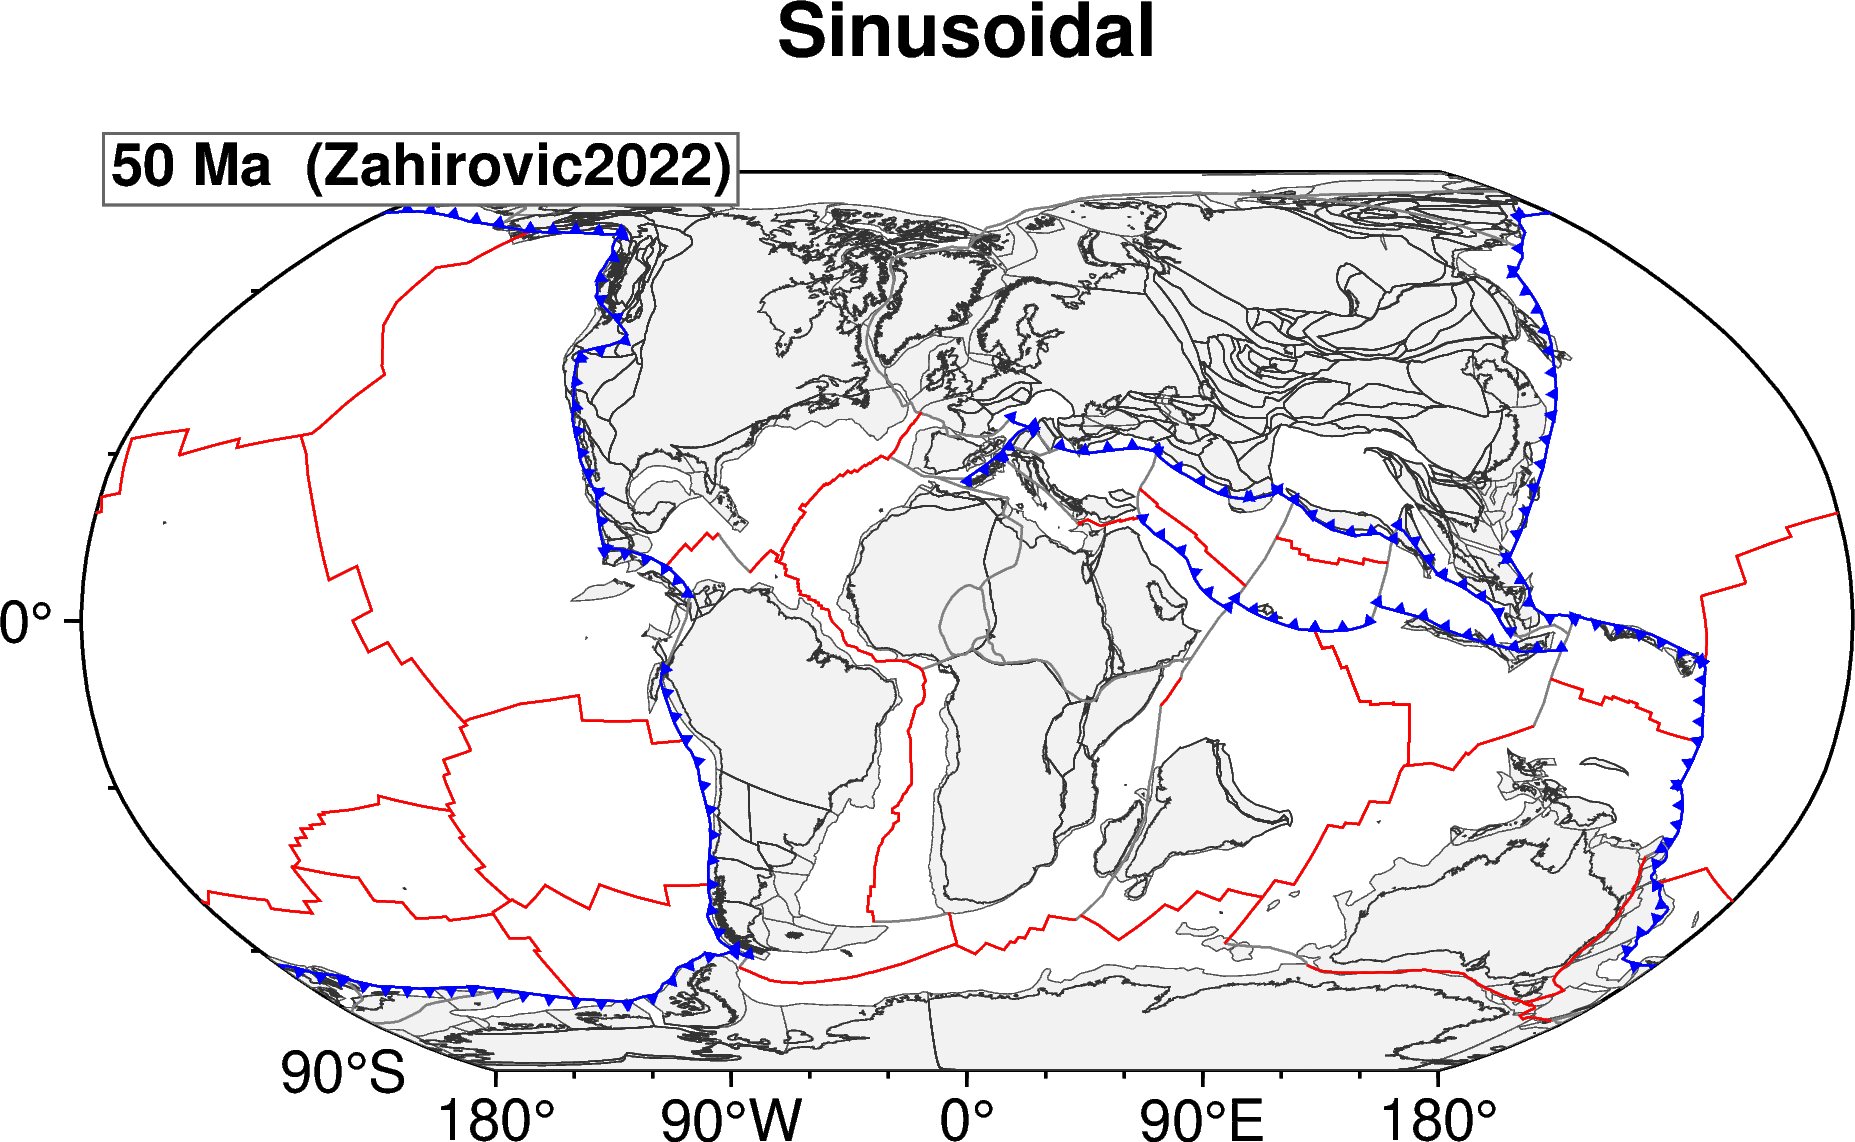

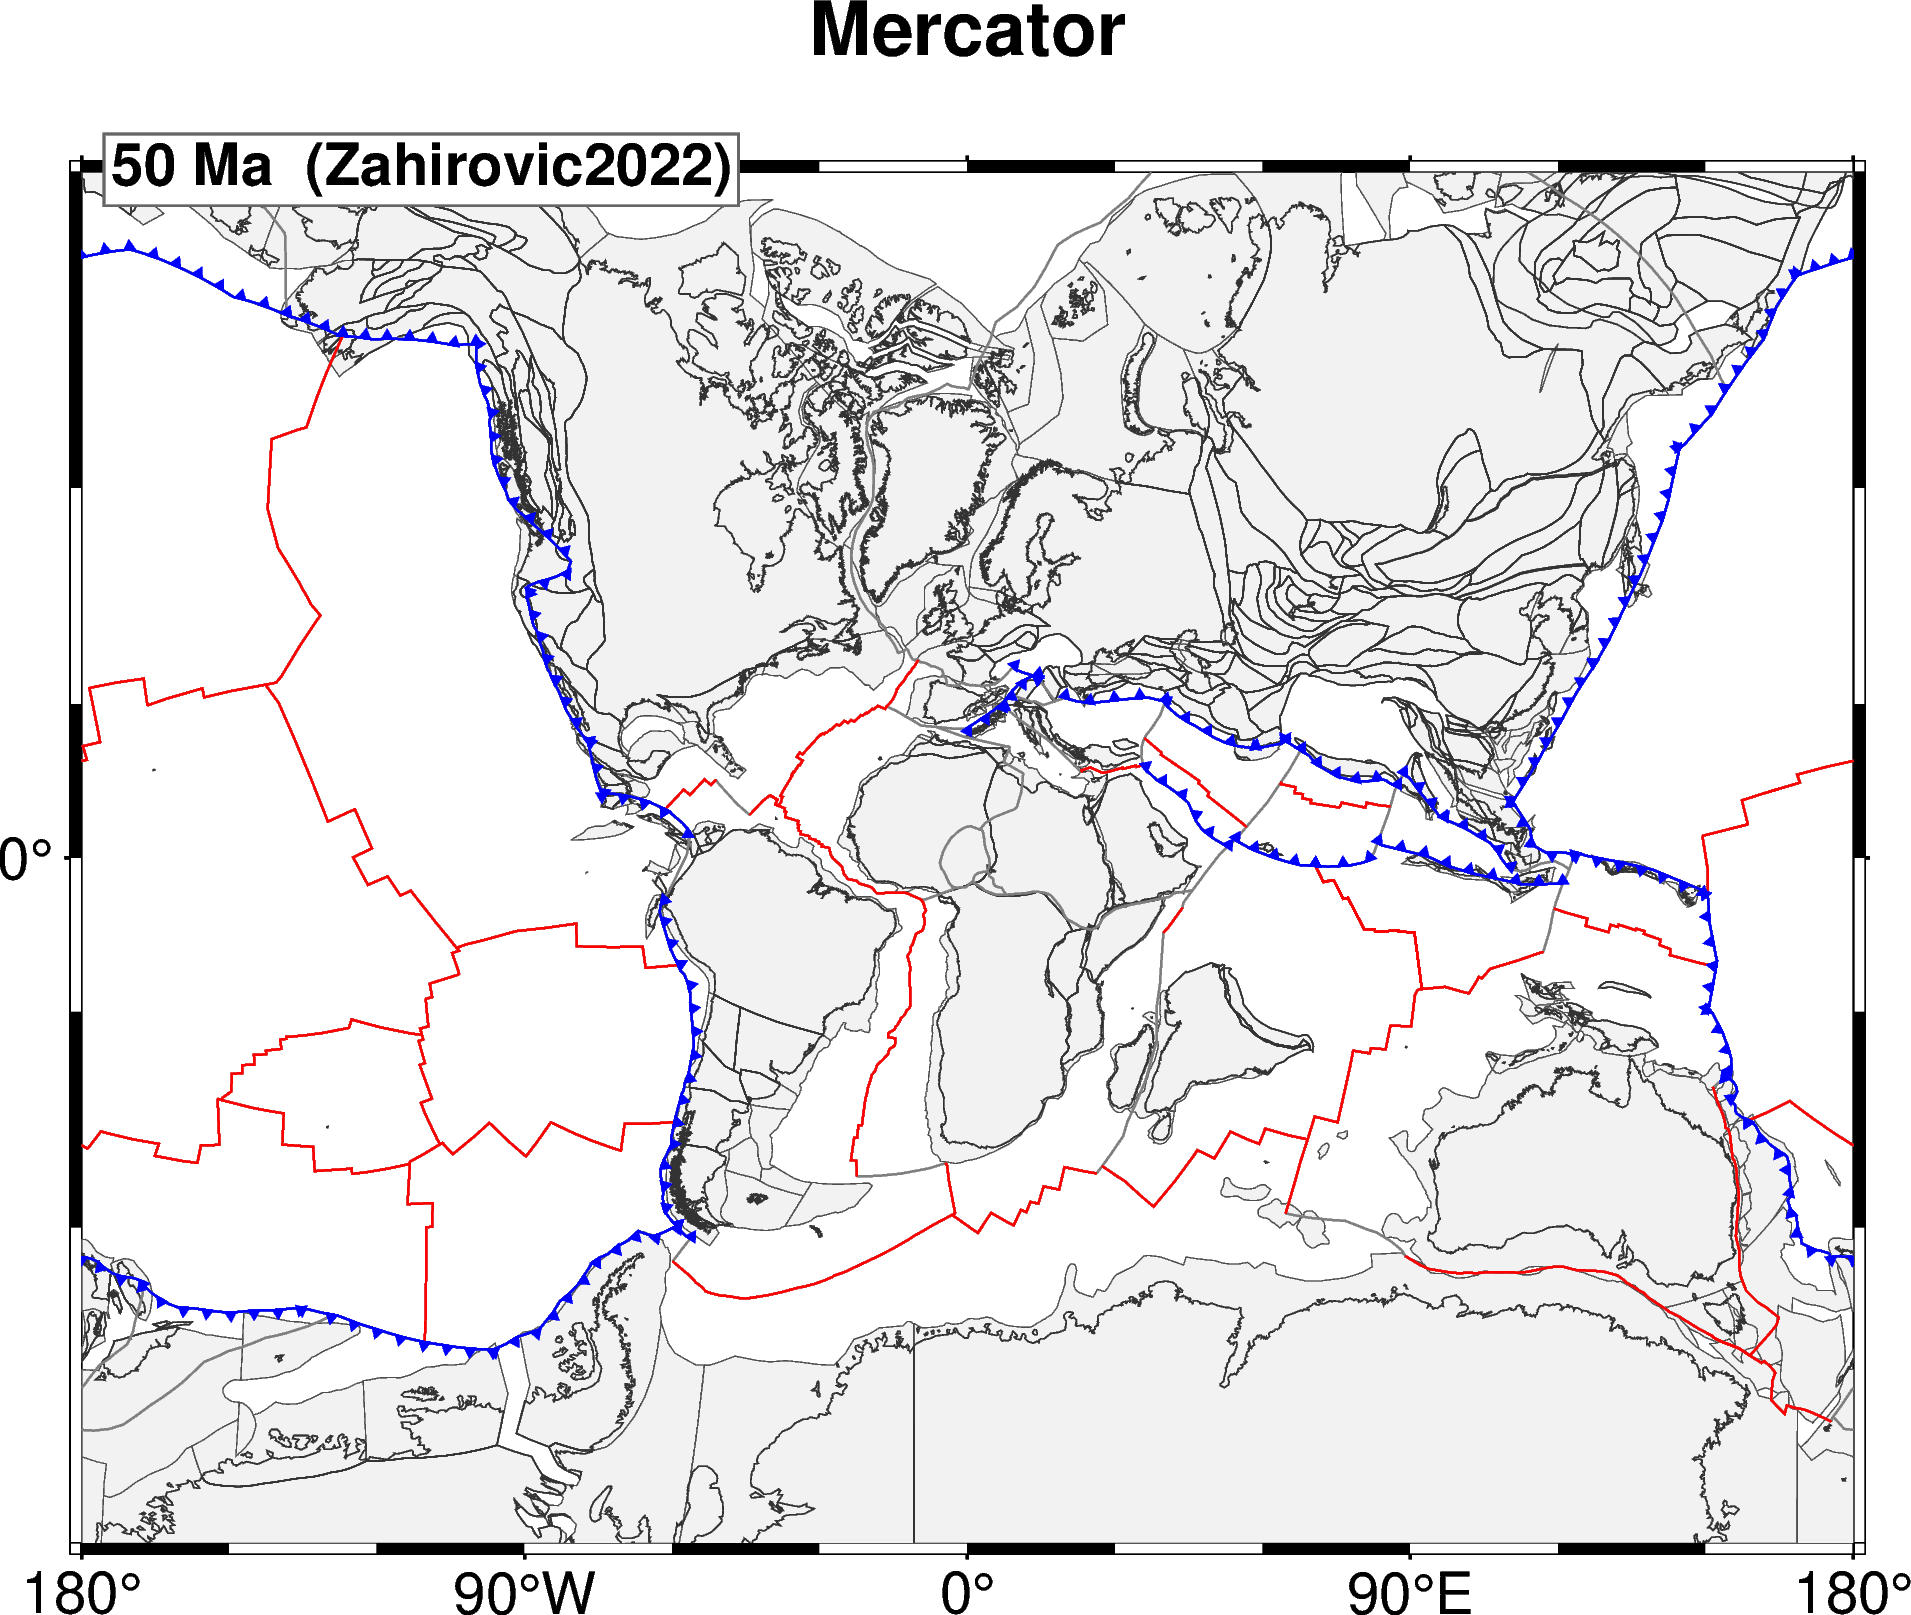

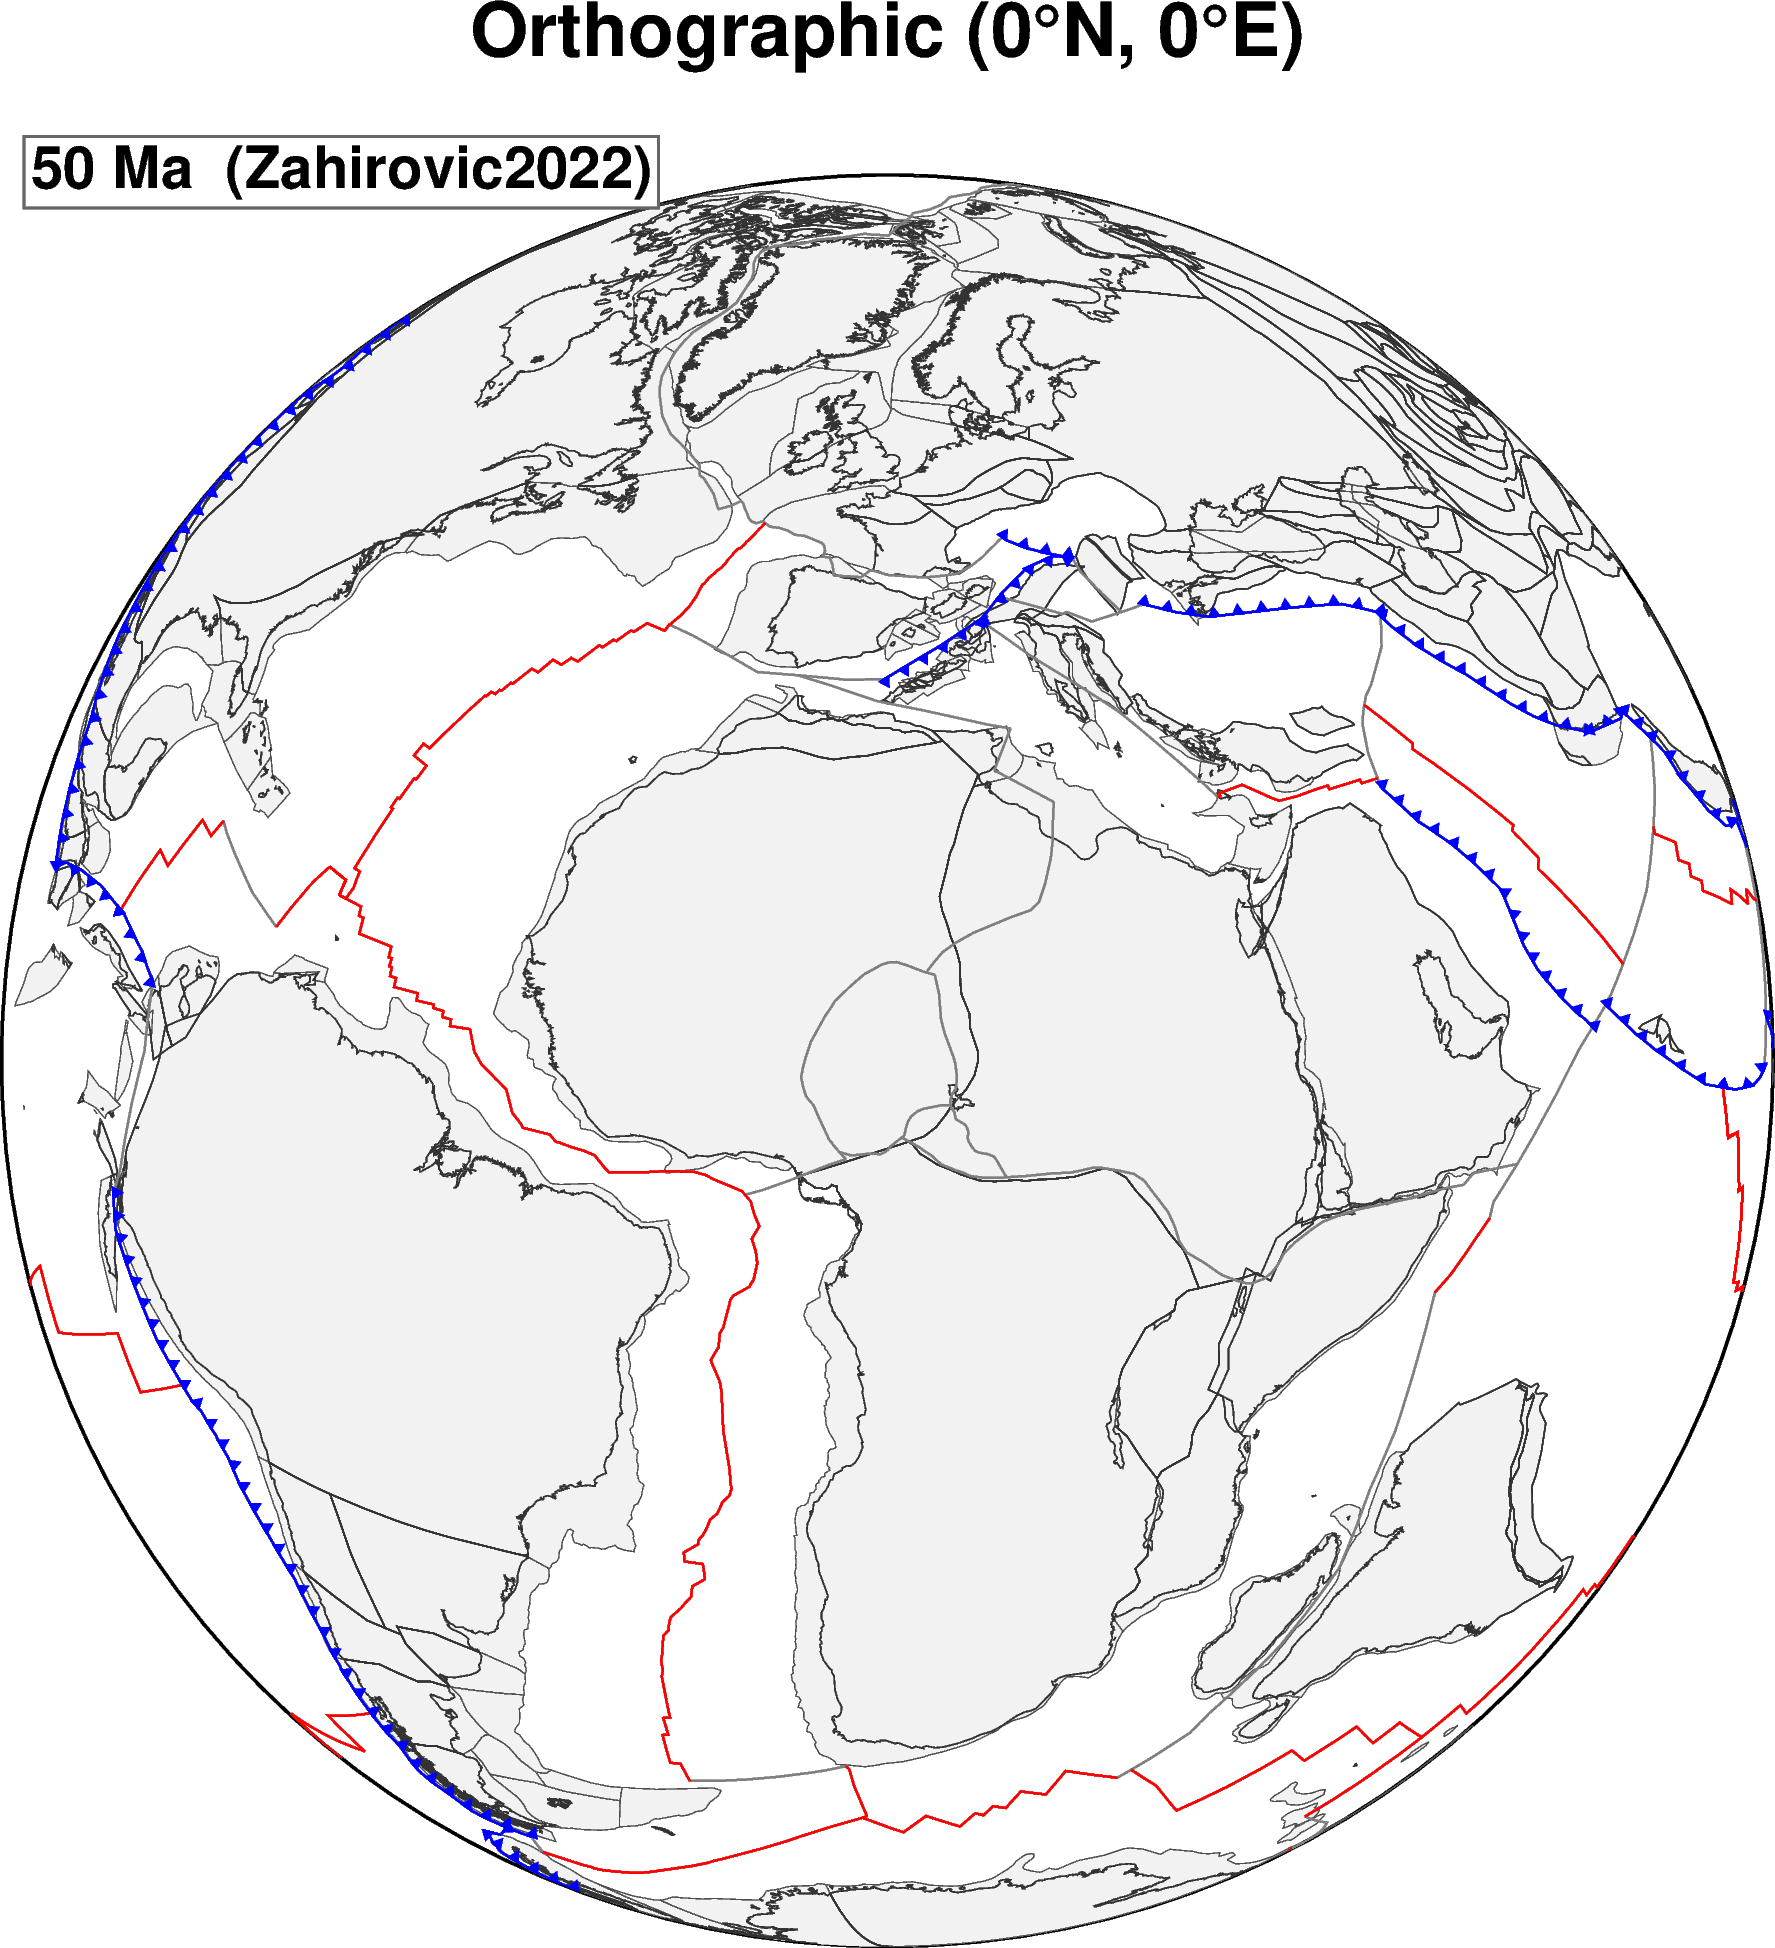

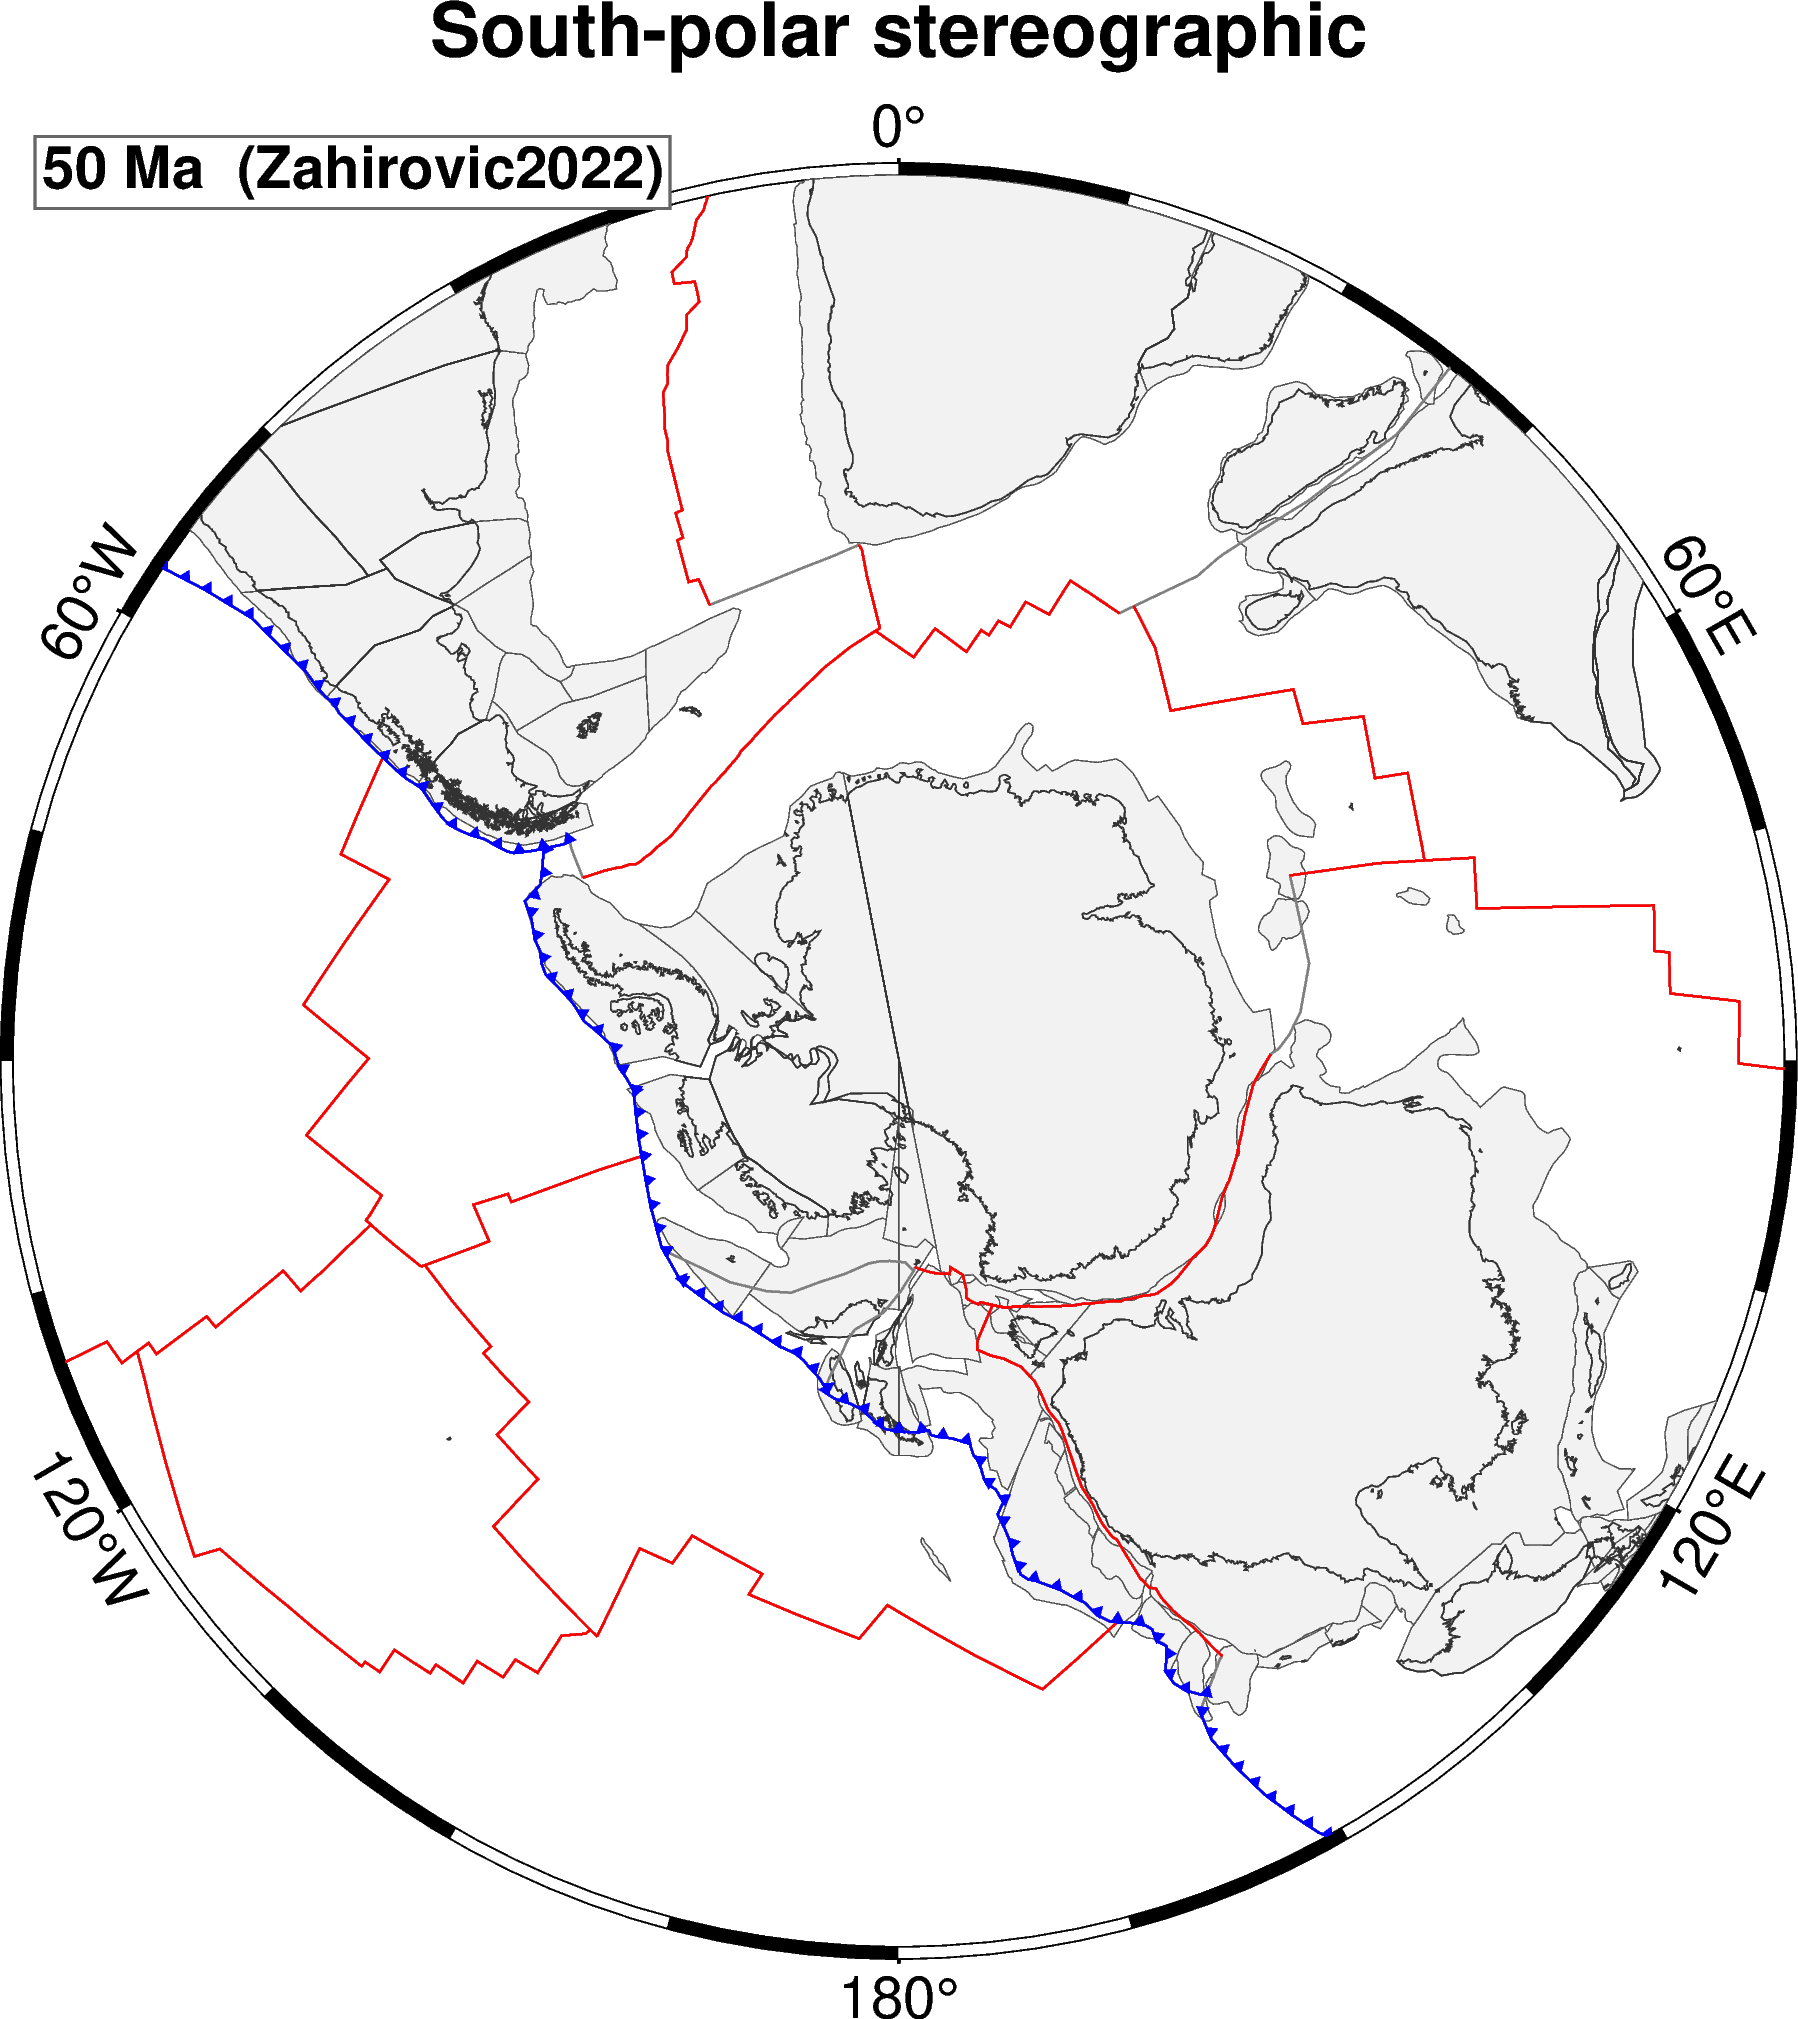

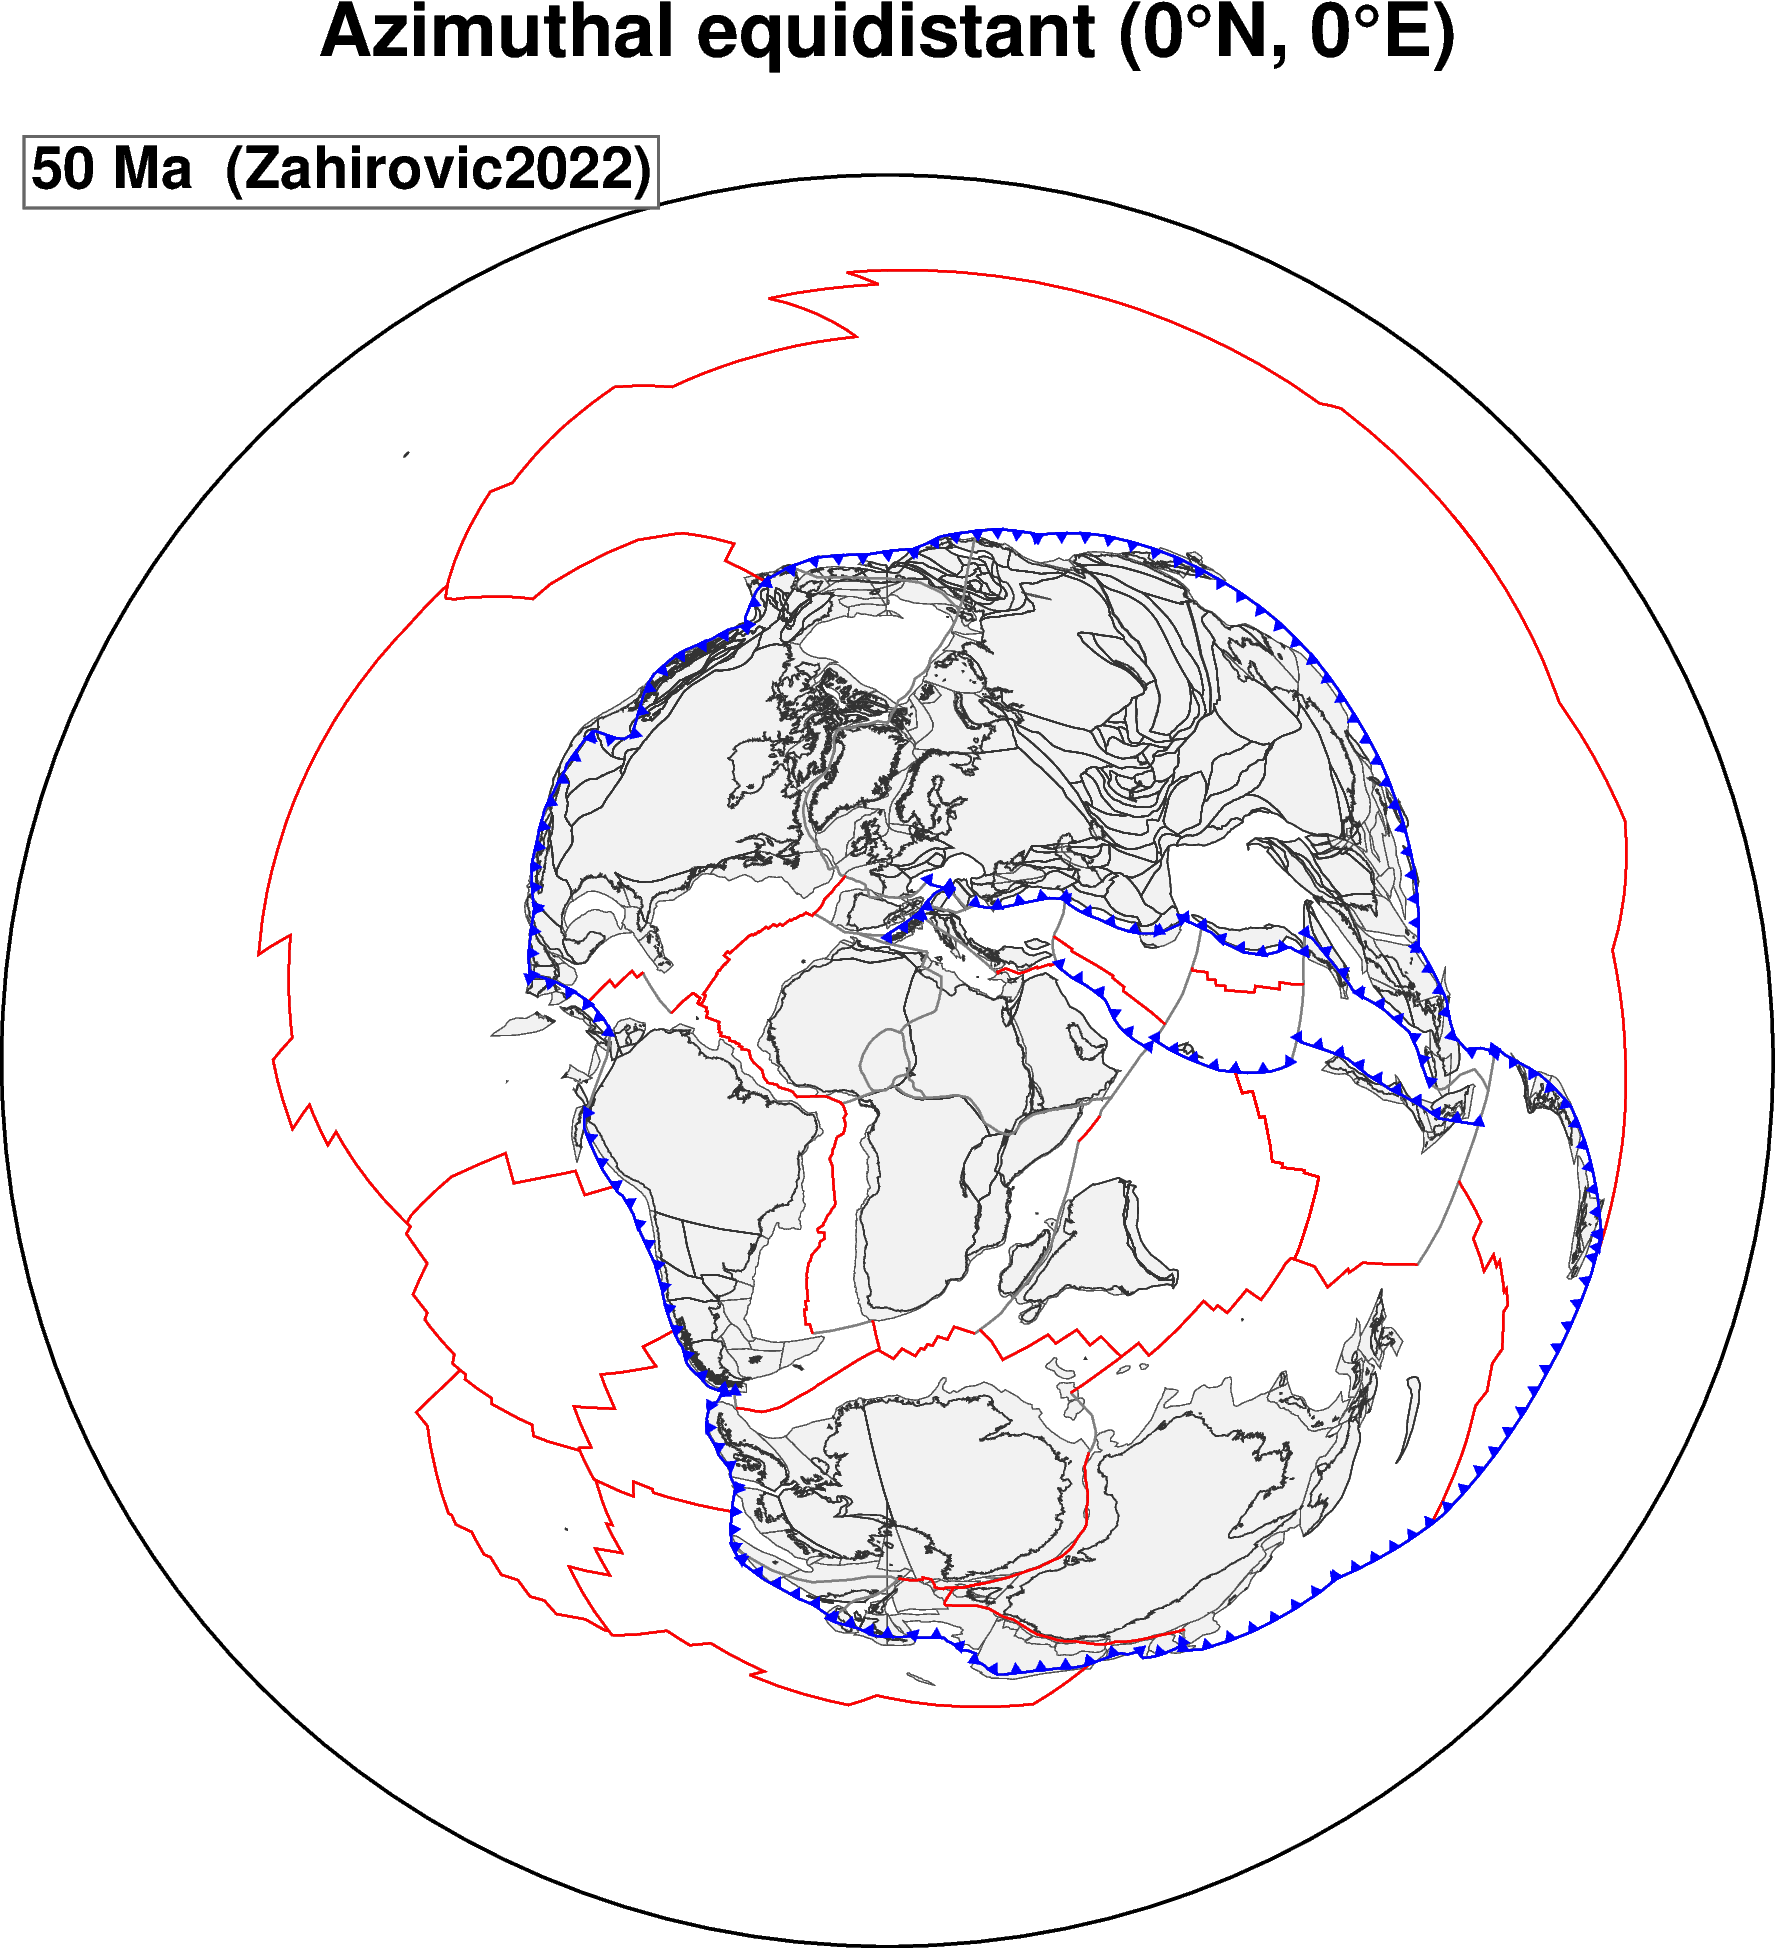

In [5]:
# Cell 4 — eight projections, one figure
# (projection, panel title, region)
# Most projections work happily with region="d" (the whole globe). Mercator
# blows up if the region includes the poles (GMT error: "Cannot include
# south/north poles with Mercator projection"), so we clip it at ±80°. For
# the south-polar stereographic we choose a south-polar cap to avoid
# unnecessary north-hemisphere distortion.
PROJECTIONS = [
    ("R0/15c",     "Robinson",                          "d"),
    ("W0/15c",     "Mollweide",                         "d"),
    ("H0/15c",     "Hammer",                            "d"),
    ("N0/15c",     "Sinusoidal",                        "d"),
    ("M0/15c",     "Mercator",                          [-180, 180, -80, 80]),
    ("G0/0/15c",   "Orthographic (0°N, 0°E)",           "d"),
    ("S0/-90/15c", "South-polar stereographic",         [-180, 180, -90, -30]),
    ("E0/0/15c",   "Azimuthal equidistant (0°N, 0°E)",  "d"),
]

# We render each projection as its own pygmt.Figure rather than packing all
# eight into a single pygmt.subplot. The reason: pygmt.subplot allocates
# identical cell dimensions to every panel, but the eight projections in
# PROJECTIONS fall into two aspect-ratio classes — pseudo-cylindrical
# (Robinson, Mollweide, Hammer, Sinusoidal) at roughly 2:1, and
# circular/square (Mercator-clipped, orthographic, polar stereographic,
# azimuthal equidistant) at roughly 1:1. A uniform cell can't host both
# without either overflowing or padding heavily, which is what produced the
# overlapping-frame mess in earlier drafts. One figure per projection is the
# clean answer and also the canonical pyGMT pattern for a cookbook.
print(f"{TIME} Ma — same data, eight projections")
for proj, title, region in PROJECTIONS:
    fig = pygmt.Figure()
    draw_panel(fig, proj, title, region)
    fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})",
             position="TL", offset="0.25c/0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40",
             no_clip=True)
    fig.show(width=750)
    display(HTML('<div style="height:1cm"></div>'))

## What the cookbook tells us

Every map projection lies — the only choice is *which* lies you are willing to tolerate. For deep-time paleo-Earth work the most common workflow is: global summary panels in Robinson or Mollweide; regional zooms in Mercator-clipped (mid-latitudes), polar stereographic (polar regions), or orthographic (continent-in-its-own-globe). The other four exist for niche cases.

## Extend this

- **Compare ages.** Re-run the whole notebook with `TIME = 200` (Pangaea) and `TIME = 0` (present-day) and notice which projections handle the polar continents best.
- **Add a graticule of small circles** around the Pacific Euler pole at 90 Ma to visualise plate-motion trajectories — see **T13**.
- **Render the difference.** Plot two reconstructions (e.g. Zahirovic 2022 vs Merdith 2021) on the same projection and difference them — that's **T04**.

## References

- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geosci. Data J.* 11, 3-10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J., Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679085
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochem. Geophys. Geosys.* 20, 5556-5564. https://doi.org/10.1029/2019GC008515

- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371-383. https://doi.org/10.1002/gdj3.146